In [292]:
import pandas as pd

df = pd.read_excel("../data/train_data.xlsx")

df.head()

,date,train_no,train_name,sched_dep_ngp,actual_dep_ngp,Destination,sched_arr,actual_arr
0,2026-05-01,61110,NGP-WR MEMU,08:00:00,08:00:00,Wardha,10:00:00,09:58:00
1,2026-05-02,61110,NGP-WR MEMU,08:00:00,08:00:00,Wardha,10:00:00,10:34:00
2,2026-05-04,61110,NGP-WR MEMU,08:00:00,08:00:00,Wardha,10:00:00,10:36:00
3,2026-05-05,61110,NGP-WR MEMU,08:00:00,08:00:00,Wardha,10:00:00,09:58:00
4,2026-05-06,61110,NGP-WR MEMU,08:00:00,08:00:00,Wardha,10:00:00,10:01:00


In [293]:
df["sched_arr"] = pd.to_datetime(df["sched_arr"], format="%H:%M:%S")
df["actual_arr"] = pd.to_datetime(df["actual_arr"], format="%H:%M:%S")
df["actual_dep_ngp"] = pd.to_datetime(df["actual_dep_ngp"], format="%H:%M:%S")
df["sched_dep_ngp"] = pd.to_datetime(df["sched_dep_ngp"], format="%H:%M:%S")

In [294]:
df["delay_min"] = (df["actual_arr"] - df["sched_arr"]).dt.total_seconds() / 60

In [295]:
df[["actual_arr", "sched_arr", "delay_min"]].head()

,actual_arr,sched_arr,delay_min
0,1900-01-01 09:58:00,1900-01-01 10:00:00,-2.0
1,1900-01-01 10:34:00,1900-01-01 10:00:00,34.0
2,1900-01-01 10:36:00,1900-01-01 10:00:00,36.0
3,1900-01-01 09:58:00,1900-01-01 10:00:00,-2.0
4,1900-01-01 10:01:00,1900-01-01 10:00:00,1.0


In [296]:
df["sched_arr"] = pd.to_datetime(df["sched_arr"], format="%H:%M:%S")
df["actual_arr"] = pd.to_datetime(df["actual_arr"], format="%H:%M:%S")
df["actual_dep_ngp"] = pd.to_datetime(df["actual_dep_ngp"], format="%H:%M:%S")
df["sched_dep_ngp"] = pd.to_datetime(df["sched_dep_ngp"], format="%H:%M:%S")

df["delay_min"] = (df["actual_arr"] - df["sched_arr"]).dt.total_seconds() / 60

df[["actual_arr", "sched_arr", "delay_min"]].head()


,actual_arr,sched_arr,delay_min
0,1900-01-01 09:58:00,1900-01-01 10:00:00,-2.0
1,1900-01-01 10:34:00,1900-01-01 10:00:00,34.0
2,1900-01-01 10:36:00,1900-01-01 10:00:00,36.0
3,1900-01-01 09:58:00,1900-01-01 10:00:00,-2.0
4,1900-01-01 10:01:00,1900-01-01 10:00:00,1.0


In [297]:
df["delay_min"].mean()

np.float64(97.54455445544555)

In [298]:
df.groupby("train_name")["delay_min"].mean()

train_name
Andaman Ex               78.538462
Gitanjali Ex            177.935484
Gondwana SF Ex           54.222222
NGP-WR MEMU              14.692308
PURI-GIMB SF Express    171.250000
Perna Ex                 18.142857
THE-LTT Special         376.500000
Name: delay_min, dtype: float64

In [299]:
reliability = df.groupby("train_name")["delay_min"].mean().sort_values()
reliability

train_name
NGP-WR MEMU              14.692308
Perna Ex                 18.142857
Gondwana SF Ex           54.222222
Andaman Ex               78.538462
PURI-GIMB SF Express    171.250000
Gitanjali Ex            177.935484
THE-LTT Special         376.500000
Name: delay_min, dtype: float64

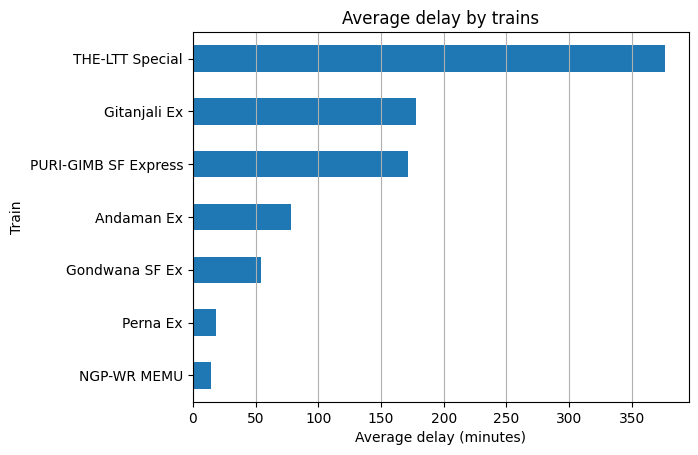

In [300]:
import matplotlib.pyplot as plt

reliability.plot(kind="barh")
plt.xlabel("Average delay (minutes)")
plt.ylabel("Train")
plt.title("Average delay by trains")
plt.grid(axis="x")

plt.show()


In [301]:
df["on_time"] = df["delay_min"] <= 15 

on_time_pct = (df.groupby("train_name")["on_time"].mean()*100).sort_values(ascending=False)

on_time_pct

train_name
NGP-WR MEMU             57.692308
Perna Ex                35.714286
Andaman Ex               7.692308
Gondwana SF Ex           0.000000
Gitanjali Ex             0.000000
PURI-GIMB SF Express     0.000000
THE-LTT Special          0.000000
Name: on_time, dtype: float64

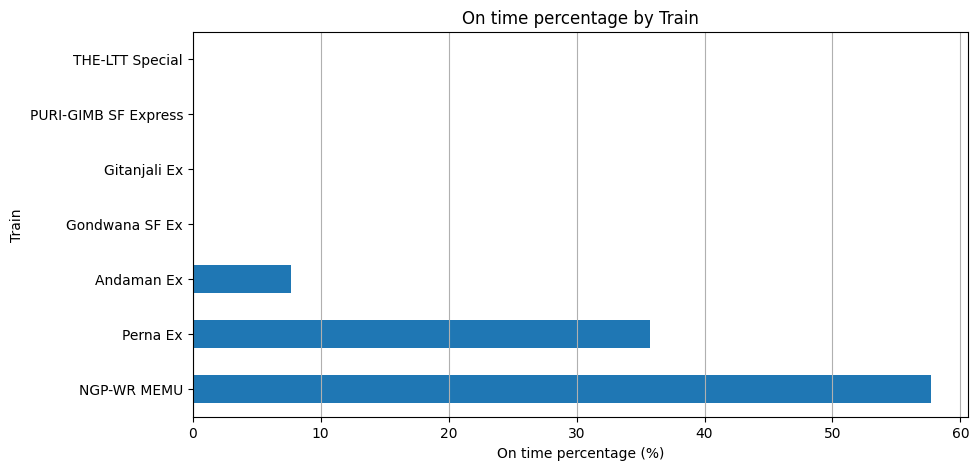

In [302]:
import matplotlib.pyplot as plt
on_time_pct.plot(kind="barh", figsize=(10,5))

plt.xlabel("On time percentage (%)")
plt.ylabel("Train")
plt.title("On time percentage by Train")
plt.grid(axis="x")

plt.show()




In [303]:
destination_delay = (df.groupby("Destination")["delay_min"].mean().sort_values())
destination_delay

Destination
Sewagram     78.538462
Wardha      100.352273
Name: delay_min, dtype: float64

In [304]:
df["day"] = df["date"].dt.day_name()

In [305]:
day_delay = (
    df.groupby("day")["delay_min"]
      .mean()
)

day_delay

day
Friday        95.500000
Monday        69.187500
Saturday      67.950000
Sunday       113.000000
Thursday      64.416667
Tuesday      206.333333
Wednesday     86.250000
Name: delay_min, dtype: float64

## Day of Week Analysis Findings

- Thursday recorded the lowest average delay (64.42 minutes).
- Tuesday recorded the highest average delay (206.33 minutes).
- Delays varied significantly across weekdays.
- Additional data collection would help confirm whether these patterns persist over time.

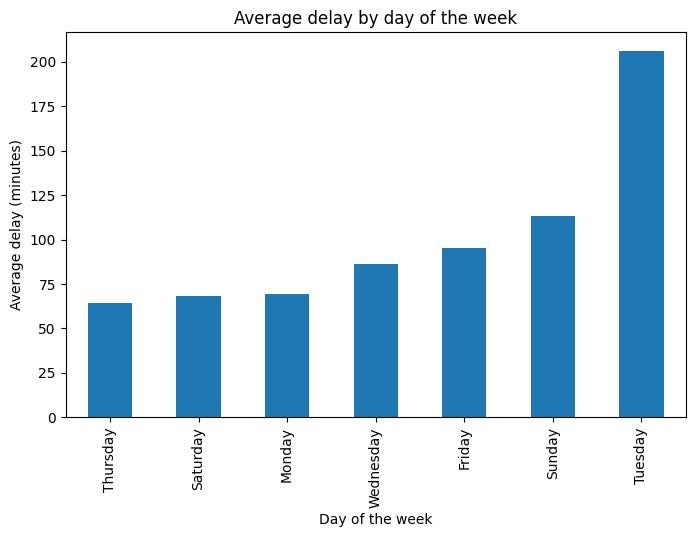

In [306]:
day_delay.sort_values().plot(kind="bar", figsize=(8,5))

plt.xlabel("Day of the week")
plt.ylabel("Average delay (minutes)")
plt.title("Average delay by day of the week")

plt.show()

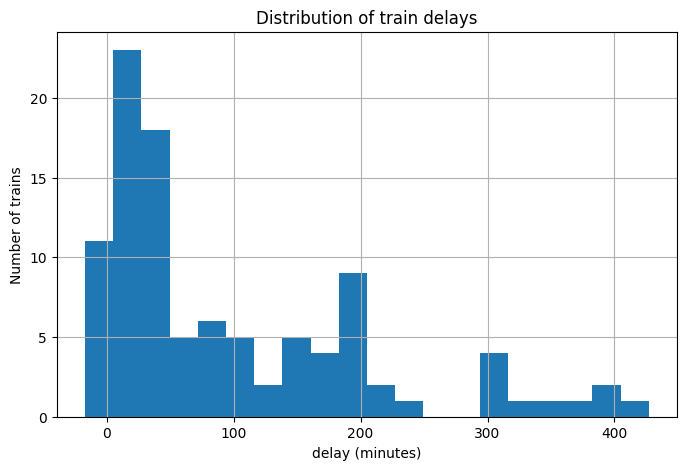

In [307]:
df["delay_min"].hist(bins=20, figsize=(8,5))
plt.xlabel("delay (minutes)")
plt.ylabel("Number of trains")
plt.title("Distribution of train delays")

plt.show()

In [308]:
reliability_score = (100 - reliability).clip(lower=0)
reliability_score

train_name
NGP-WR MEMU             85.307692
Perna Ex                81.857143
Gondwana SF Ex          45.777778
Andaman Ex              21.461538
PURI-GIMB SF Express     0.000000
Gitanjali Ex             0.000000
THE-LTT Special          0.000000
Name: delay_min, dtype: float64

In [309]:
df["train_name"].unique()

<StringArray>
[         'NGP-WR MEMU', 'PURI-GIMB SF Express',      'THE-LTT Special',
         'Gitanjali Ex',       'Gondwana SF Ex',             'Perna Ex',
           'Andaman Ex']
Length: 7, dtype: str

In [310]:
df["train_name"].value_counts()

train_name
Gitanjali Ex            31
NGP-WR MEMU             26
Perna Ex                14
Andaman Ex              13
Gondwana SF Ex           9
PURI-GIMB SF Express     4
THE-LTT Special          4
Name: count, dtype: int64

In [311]:
train_summary = df.groupby("train_name").agg({"delay_min": "mean", "on_time": "mean" })
train_summary

,delay_min,on_time
train_name,,
Andaman Ex,78.538462,0.076923
Gitanjali Ex,177.935484,0.000000
Gondwana SF Ex,54.222222,0.000000
NGP-WR MEMU,14.692308,0.576923
PURI-GIMB SF Express,171.250000,0.000000
Perna Ex,18.142857,0.357143
THE-LTT Special,376.500000,0.000000


In [312]:
train_summary = train_summary["on_time"] * 100
train_summary


train_name
Andaman Ex               7.692308
Gitanjali Ex             0.000000
Gondwana SF Ex           0.000000
NGP-WR MEMU             57.692308
PURI-GIMB SF Express     0.000000
Perna Ex                35.714286
THE-LTT Special          0.000000
Name: on_time, dtype: float64

In [313]:
df["actual_arr"].head()

0   1900-01-01 09:58:00
1   1900-01-01 10:34:00
2   1900-01-01 10:36:00
3   1900-01-01 09:58:00
4   1900-01-01 10:01:00
Name: actual_arr, dtype: datetime64[us]

In [314]:
start_time = pd.to_datetime("09:30:00").time()
end_time = pd.to_datetime("11:30:00").time()

In [315]:
df["within_window"] = ((df["actual_arr"].dt.time >= start_time) &
                       (df["actual_arr"].dt.time <= end_time))


In [390]:
print(len(df))

101


In [316]:
window_success = (df.groupby("train_name")["within_window"].mean()*100).sort_values()
window_success

train_name
THE-LTT Special           0.000000
PURI-GIMB SF Express     25.000000
Gitanjali Ex             41.935484
Andaman Ex               61.538462
Perna Ex                 64.285714
Gondwana SF Ex           88.888889
NGP-WR MEMU             100.000000
Name: within_window, dtype: float64

In [317]:
train_summary = df.groupby("train_name").agg({
    "delay_min": "mean",
    "on_time": "mean",
    "within_window": "mean"
})

train_summary["on_time"] *= 100
train_summary["within_window"] *= 100

train_summary = train_summary.round(2)
train_summary

,delay_min,on_time,within_window
train_name,,,
Andaman Ex,78.54,7.69,61.54
Gitanjali Ex,177.94,0.00,41.94
Gondwana SF Ex,54.22,0.00,88.89
NGP-WR MEMU,14.69,57.69,100.00
PURI-GIMB SF Express,171.25,0.00,25.00
Perna Ex,18.14,35.71,64.29
THE-LTT Special,376.50,0.00,0.00


In [318]:
train_summary["score"] = (
    train_summary["within_window"]*0.5 + train_summary["on_time"]*0.3 - train_summary["delay_min"]*0.2)


In [319]:
train_summary.sort_values("score", ascending=False)

,delay_min,on_time,within_window,score
train_name,,,,
NGP-WR MEMU,14.69,57.69,100.00,64.369
Perna Ex,18.14,35.71,64.29,39.230
Gondwana SF Ex,54.22,0.00,88.89,33.601
Andaman Ex,78.54,7.69,61.54,17.369
Gitanjali Ex,177.94,0.00,41.94,-14.618
PURI-GIMB SF Express,171.25,0.00,25.00,-21.750
THE-LTT Special,376.50,0.00,0.00,-75.300


In [320]:
train_summary["delay_score"] = (100 - train_summary["delay_min"]).clip(lower=0)


In [321]:
arrival_time_summary = (df.groupby("train_name")["actual_arr"].agg(["min", "max"]))
arrival_time_summary

,min,max
train_name,,
Andaman Ex,1900-01-01 10:12:00,1900-01-01 13:23:00
Gitanjali Ex,1900-01-01 09:43:00,1900-01-01 15:13:00
Gondwana SF Ex,1900-01-01 09:45:00,1900-01-01 12:00:00
NGP-WR MEMU,1900-01-01 09:43:00,1900-01-01 10:42:00
PURI-GIMB SF Express,1900-01-01 11:07:00,1900-01-01 12:43:00
Perna Ex,1900-01-01 09:18:00,1900-01-01 09:51:00
THE-LTT Special,1900-01-01 14:33:00,1900-01-01 16:27:00


In [322]:
df["arrival_minutes"] = (df["actual_arr"].dt.hour * 60 + df["actual_arr"].dt.minute)


In [323]:
consistency = (
    df.groupby("train_name")["arrival_minutes"]
      .std()
      .sort_values()
)

consistency

train_name
Perna Ex                 8.690022
NGP-WR MEMU             16.785158
PURI-GIMB SF Express    43.223258
Gondwana SF Ex          46.313545
THE-LTT Special         50.163067
Andaman Ex              59.044638
Gitanjali Ex            90.961873
Name: arrival_minutes, dtype: float64

In [324]:
train_summary["consistency"] = consistency
train_summary

,delay_min,on_time,within_window,score,delay_score,consistency
train_name,,,,,,
Andaman Ex,78.54,7.69,61.54,17.369,21.46,59.044638
Gitanjali Ex,177.94,0.00,41.94,-14.618,0.00,90.961873
Gondwana SF Ex,54.22,0.00,88.89,33.601,45.78,46.313545
NGP-WR MEMU,14.69,57.69,100.00,64.369,85.31,16.785158
PURI-GIMB SF Express,171.25,0.00,25.00,-21.750,0.00,43.223258
Perna Ex,18.14,35.71,64.29,39.230,81.86,8.690022
THE-LTT Special,376.50,0.00,0.00,-75.300,0.00,50.163067


In [325]:
df["day"] = df["date"].dt.day_name()
df[["date", "day"]].head()

,date,day
0,2026-05-01,Friday
1,2026-05-02,Saturday
2,2026-05-04,Monday
3,2026-05-05,Tuesday
4,2026-05-06,Wednesday


In [326]:
df.groupby(["day", "train_name"])
df.shape

(101, 13)

In [327]:
train_summary["records"] = (
    df.groupby("train_name")
      .size()
)
train_summary

,delay_min,on_time,within_window,score,delay_score,consistency,records
train_name,,,,,,,
Andaman Ex,78.54,7.69,61.54,17.369,21.46,59.044638,13
Gitanjali Ex,177.94,0.00,41.94,-14.618,0.00,90.961873,31
Gondwana SF Ex,54.22,0.00,88.89,33.601,45.78,46.313545,9
NGP-WR MEMU,14.69,57.69,100.00,64.369,85.31,16.785158,26
PURI-GIMB SF Express,171.25,0.00,25.00,-21.750,0.00,43.223258,4
Perna Ex,18.14,35.71,64.29,39.230,81.86,8.690022,14
THE-LTT Special,376.50,0.00,0.00,-75.300,0.00,50.163067,4


In [328]:
avg_arrival = (
    df.groupby("train_name")["arrival_minutes"]
      .mean()
)

In [329]:
avg_arrival = (
    df.groupby(["day", "train_name"])["arrival_minutes"]
      .mean()
      .round(0)
)

avg_arrival

day        train_name          
Friday     Gitanjali Ex            709.0
           NGP-WR MEMU             610.0
Monday     Andaman Ex              664.0
           Gitanjali Ex            648.0
           Gondwana SF Ex          638.0
           NGP-WR MEMU             623.0
Saturday   Gitanjali Ex            718.0
           Gondwana SF Ex          609.0
           NGP-WR MEMU             626.0
           Perna Ex                569.0
Sunday     Andaman Ex              703.0
           Gitanjali Ex            694.0
           PURI-GIMB SF Express    719.0
           Perna Ex                578.0
Thursday   Andaman Ex              663.0
           Gitanjali Ex            654.0
           NGP-WR MEMU             604.0
Tuesday    Gitanjali Ex            765.0
           NGP-WR MEMU             606.0
           THE-LTT Special         936.0
Wednesday  Gitanjali Ex            752.0
           NGP-WR MEMU             618.0
           Perna Ex                572.0
Name: arrival_minutes, dt

In [330]:
day_train_summary = (
    df.groupby(["day", "train_name"])
      .agg({
          "delay_min": "mean",
          "on_time": "mean",
          "arrival_minutes": "mean"
      })
      .round(2)
)

day_train_summary

delay_min  on_time  arrival_minutes
day       train_name                                               
Friday    Gitanjali Ex             181.00     0.00           709.00
          NGP-WR MEMU               10.00     0.80           610.00
Monday    Andaman Ex                63.50     0.00           663.50
          Gitanjali Ex             119.75     0.00           647.75
          Gondwana SF Ex            70.25     0.00           638.25
          NGP-WR MEMU               23.25     0.50           623.25
Saturday  Gitanjali Ex             190.40     0.00           718.40
          Gondwana SF Ex            41.40     0.00           609.40
          NGP-WR MEMU               26.00     0.20           626.00
          Perna Ex                  14.00     0.20           569.00
Sunday    Andaman Ex               103.00     0.00           703.00
          Gitanjali Ex             166.00     0.00           694.00
          PURI-GIMB SF Express     171.25     0.00           719.25
          Perna Ex                  23.40     0.20           578.40
Thursday  Andaman Ex                63.00     0.25           663.00
          Gitanjali Ex             126.25     0.00           654.25
          NGP-WR MEMU                4.00     0.75           604.00
Tuesday   Gitanjali Ex             237.00     0.00           765.00
          NGP-WR MEMU                5.50     0.75           605.50
          THE-LTT Special          376.50     0.00           936.50
Wednesday Gitanjali Ex             224.25     0.00           752.25
          NGP-WR MEMU               17.75     0.50           617.75
          Perna Ex                  16.75     0.75           571.75

In [331]:
def filter_day_destination(df, day, destination):

    filtered = df[
        (df["day"] == day)
        &
        (df["Destination"] == destination)
    ]

    return filtered

In [332]:
test = filter_day_destination(
    df,
    "Tuesday",
    "Wardha"
)

test.head()

,date,train_no,train_name,sched_dep_ngp,actual_dep_ngp,Destination,sched_arr,actual_arr,delay_min,on_time,day,within_window,arrival_minutes
3,2026-05-05,61110,NGP-WR MEMU,1900-01-01 08:00:00,1900-01-01 08:00:00,Wardha,1900-01-01 10:00:00,1900-01-01 09:58:00,-2.0,True,Tuesday,True,598
9,2026-05-12,61110,NGP-WR MEMU,1900-01-01 08:00:00,1900-01-01 08:00:00,Wardha,1900-01-01 10:00:00,1900-01-01 10:03:00,3.0,True,Tuesday,True,603
15,2026-05-19,61110,NGP-WR MEMU,1900-01-01 08:00:00,1900-01-01 08:00:00,Wardha,1900-01-01 10:00:00,1900-01-01 10:22:00,22.0,False,Tuesday,True,622
21,2026-05-26,61110,NGP-WR MEMU,1900-01-01 08:00:00,1900-01-01 08:00:00,Wardha,1900-01-01 10:00:00,1900-01-01 09:59:00,-1.0,True,Tuesday,True,599
30,2026-05-05,8609,THE-LTT Special,1900-01-01 08:10:00,1900-01-01 12:50:00,Wardha,1900-01-01 09:20:00,1900-01-01 14:33:00,313.0,False,Tuesday,False,873


In [333]:
def calculate_window_success(data, start_time, end_time):

    within_window = (
        (data["actual_arr"].dt.time >= start_time)
        &
        (data["actual_arr"].dt.time <= end_time)
    )

    return within_window.mean() * 100

In [334]:
start_time = pd.to_datetime("09:30:00").time()
end_time = pd.to_datetime("11:30:00").time()

results = []

for train in df["train_name"].unique():
    train_data = df[df["train_name"] == train]
    success_rate = calculate_window_success(train_data, start_time, end_time)
    results.append([train, success_rate])
    
    results

In [335]:
window_ranking = pd.DataFrame(
    results,
    columns=["train_name", "window_success"]
)

window_ranking.sort_values(
    "window_success",
    ascending=False
)

,train_name,window_success
0,NGP-WR MEMU,100.000000
4,Gondwana SF Ex,88.888889
5,Perna Ex,64.285714
6,Andaman Ex,61.538462
3,Gitanjali Ex,41.935484
1,PURI-GIMB SF Express,25.000000
2,THE-LTT Special,0.000000


In [336]:
avg_arrival = (
    df.groupby("train_name")["arrival_minutes"].mean().round()
)
avg_arrival

train_name
Andaman Ex              679.0
Gitanjali Ex            706.0
Gondwana SF Ex          622.0
NGP-WR MEMU             615.0
PURI-GIMB SF Express    719.0
Perna Ex                573.0
THE-LTT Special         936.0
Name: arrival_minutes, dtype: float64

In [337]:
train_summary["avg_arrival"] = avg_arrival 
train_summary

,delay_min,on_time,within_window,score,delay_score,consistency,records,avg_arrival
train_name,,,,,,,,
Andaman Ex,78.54,7.69,61.54,17.369,21.46,59.044638,13,679.0
Gitanjali Ex,177.94,0.00,41.94,-14.618,0.00,90.961873,31,706.0
Gondwana SF Ex,54.22,0.00,88.89,33.601,45.78,46.313545,9,622.0
NGP-WR MEMU,14.69,57.69,100.00,64.369,85.31,16.785158,26,615.0
PURI-GIMB SF Express,171.25,0.00,25.00,-21.750,0.00,43.223258,4,719.0
Perna Ex,18.14,35.71,64.29,39.230,81.86,8.690022,14,573.0
THE-LTT Special,376.50,0.00,0.00,-75.300,0.00,50.163067,4,936.0


In [339]:
minutes_to_time(615)

'10:15'

In [340]:
train_summary["arrival_time"] = (
    train_summary["avg_arrival"]
    .apply(minutes_to_time)
)

In [341]:
train_summary[
    ["arrival_time",
     "consistency",
     "records",
     "window_success" if "window_success" in train_summary.columns else "within_window"]
]

,arrival_time,consistency,records,within_window
train_name,,,,
Andaman Ex,11:19,59.044638,13,61.54
Gitanjali Ex,11:46,90.961873,31,41.94
Gondwana SF Ex,10:22,46.313545,9,88.89
NGP-WR MEMU,10:15,16.785158,26,100.00
PURI-GIMB SF Express,11:59,43.223258,4,25.00
Perna Ex,9:33,8.690022,14,64.29
THE-LTT Special,15:36,50.163067,4,0.00


In [386]:
def recommend_train(df, destination, day, start_time, end_time):

    filtered = df[(df["Destination"] == destination) & (df["day"] == day)]
    if filtered.empty:
        return None, {
            "error": "No trains found for the selected destination and day."
        }
    results = []

    for train in filtered["train_name"].unique():
        train_data = filtered[filtered["train_name"] == train]
        window_success = calculate_window_success(train_data, start_time, end_time)
        consistency = train_data["arrival_minutes"].std()
        records = len(train_data)
        avg_arrival = minutes_to_time(train_data["arrival_minutes"].mean())
        results.append([train, window_success, consistency, records, avg_arrival])
    recommendation_df = pd.DataFrame(results, columns=["train_name", "window_success", "consistency", "records", "avg_arrival"])
    recommendation_df = recommendation_df.sort_values(by=["window_success", "consistency"],ascending=[False, True])
    best_train = recommendation_df.iloc[0]
    train_name = best_train["train_name"]

    train_data = df[
    df["train_name"] == train_name]

    scheduled_departure = (
    train_data["sched_dep_ngp"]
    .iloc[0])

    avg_departure_delay = (
    train_data["departure_delay"]
    .mean())

    expected_departure = (
    scheduled_departure
    + pd.Timedelta(minutes=avg_departure_delay))
    top_3 = recommendation_df[
    recommendation_df["window_success"] >= 50].head(3)
    top_3["reliability"] = (
    top_3["consistency"]
    .apply(get_reliability))

    alternatives = top_3.iloc[1:]

    alternative_list = []

    for _, row in alternatives.iterrows():

        alternative_list.append({
        "train_name": row["train_name"],
        "arrival": row["avg_arrival"],
        "reliability": row["reliability"],
        "window_success": float(
            round(row["window_success"], 2)
        )
        })

    reliability = get_reliability(best_train["consistency"])
    confidence = get_confidence(best_train["records"])

    recommendation = {

    "alternatives": alternative_list,    
    "scheduled_departure": scheduled_departure.strftime("%H:%M"),
    "expected_departure": expected_departure.strftime("%H:%M"),
    "avg_departure_delay": float(round(avg_departure_delay, 2)),
    "train_name": best_train["train_name"],
    "expected_arrival": best_train["avg_arrival"],
    "reliability": reliability,
    "window_success": float(round(best_train["window_success"], 2)),
    "confidence": confidence}
   

    return recommendation_df, recommendation


In [387]:
filtered = df[
    (df["Destination"] == "Wardha") &
    (df["day"] == "Friday")
]

len(filtered)

10

In [388]:
recommend_train(
    df,
    "Wardha",
    "Friday",
    pd.to_datetime("09:30").time(),
    pd.to_datetime("11:30").time()
)

(     train_name  window_success  consistency  records avg_arrival
 0   NGP-WR MEMU           100.0    13.095801        5       10:10
 1  Gitanjali Ex            20.0    85.296542        5       11:49,
 {'alternatives': [],
  'scheduled_departure': '08:00',
  'expected_departure': '08:00',
  'avg_departure_delay': 0.0,
  'train_name': 'NGP-WR MEMU',
  'expected_arrival': '10:10',
  'reliability': 'Excellent',
  'window_success': 100.0,
  'confidence': 'Low (Limited historical data)'})

In [389]:
recommend_train(
    df,
    "Wardha",
    "Monday",
    pd.to_datetime("09:30").time(),
    pd.to_datetime("11:30").time()
)

(       train_name  window_success  consistency  records avg_arrival
 0     NGP-WR MEMU           100.0    18.571932        4       10:23
 1    Gitanjali Ex            75.0    55.391786        4       10:47
 2  Gondwana SF Ex            75.0    55.536024        4       10:38,
 {'alternatives': [{'train_name': 'Gitanjali Ex',
    'arrival': '10:47',
    'reliability': 'Average',
    'window_success': 75.0},
   {'train_name': 'Gondwana SF Ex',
    'arrival': '10:38',
    'reliability': 'Average',
    'window_success': 75.0}],
  'scheduled_departure': '08:00',
  'expected_departure': '08:00',
  'avg_departure_delay': 0.0,
  'train_name': 'NGP-WR MEMU',
  'expected_arrival': '10:23',
  'reliability': 'Good',
  'window_success': 100.0,
  'confidence': 'Low (Limited historical data)'})

In [348]:
alternatives = top_3.iloc[1:]

alternative_list = []

for _, row in alternatives.iterrows():

    alternative_list.append({
        "train_name": row["train_name"],
        "arrival": row["avg_arrival"],
        "reliability": row["reliability"],
        "window_success": float(
            round(row["window_success"], 2)
        )
    })

alternative_list

[]

In [344]:
alternatives = top_3.iloc[1:]

alternatives

,train_name,window_success,consistency,records,avg_arrival,reliability


In [374]:
recommendation_df, recommendation = recommend_train(
    df,
    "Wardha",
    "Tuesday",
    pd.to_datetime("09:30").time(),
    pd.to_datetime("11:30").time()
)
recommendation

{'alternatives': [{'train_name': 'Gitanjali Ex',
   'arrival': '12:45',
   'reliability': 'Poor',
   'window_success': 25.0}],
 'scheduled_departure': '08:00',
 'expected_departure': '08:00',
 'avg_departure_delay': np.float64(0.0),
 'train_name': 'NGP-WR MEMU',
 'expected_arrival': '10:05',
 'reliability': 'Excellent',
 'window_success': 100.0,
 'confidence': 'Low (Limited historical data)'}

In [ ]:
df.columns


Index(['date', 'train_no', 'train_name', 'sched_dep_ngp', 'actual_dep_ngp',
       'Destination', 'sched_arr', 'actual_arr', 'delay_min', 'on_time', 'day',
       'within_window', 'arrival_minutes', 'departure_delay'],
      dtype='str')

In [349]:
df["departure_delay"] = (
    (
        df["actual_dep_ngp"].dt.hour * 60
        + df["actual_dep_ngp"].dt.minute
    )
    -
    (
        df["sched_dep_ngp"].dt.hour * 60
        + df["sched_dep_ngp"].dt.minute
    )
)

In [350]:
df[["train_name", "departure_delay"]].head()

,train_name,departure_delay
0,NGP-WR MEMU,0
1,NGP-WR MEMU,0
2,NGP-WR MEMU,0
3,NGP-WR MEMU,0
4,NGP-WR MEMU,0


In [351]:
df["departure_delay"].describe()

count    101.000000
mean      75.346535
std      102.578793
min        0.000000
25%        0.000000
50%        9.000000
75%      136.000000
max      363.000000
Name: departure_delay, dtype: float64

In [352]:
departure_summary = (
    df.groupby("train_name")["departure_delay"]
    .mean()
    .round(2)
)

departure_summary

train_name
Andaman Ex               45.00
Gitanjali Ex            155.55
Gondwana SF Ex           30.56
NGP-WR MEMU               0.00
PURI-GIMB SF Express    153.00
Perna Ex                  0.00
THE-LTT Special         329.00
Name: departure_delay, dtype: float64

In [353]:
memu_data = df[
    df["train_name"] == "NGP-WR MEMU"
]

memu_data["sched_dep_ngp"].iloc[0]

Timestamp('1900-01-01 08:00:00')

In [354]:
train_name = best_train["train_name"]

train_data = df[
    df["train_name"] == train_name
]

scheduled_departure = (
    train_data["sched_dep_ngp"]
    .iloc[0]
)

scheduled_departure

Timestamp('1900-01-01 08:00:00')

In [355]:
scheduled_departure.strftime("%H:%M")

'08:00'

In [356]:
departure_summary["NGP-WR MEMU"]

np.float64(0.0)

In [358]:
train_name = best_train["train_name"]

train_data = df[
    df["train_name"] == train_name
]

scheduled_departure = (
    train_data["sched_dep_ngp"]
    .iloc[0]
)

avg_departure_delay = (
    train_data["departure_delay"]
    .mean()
)

expected_departure = (
    scheduled_departure
    + pd.Timedelta(minutes=avg_departure_delay)
)

print("Scheduled:", scheduled_departure.strftime("%H:%M"))
print("Expected:", expected_departure.strftime("%H:%M"))
print("Average Delay:", round(avg_departure_delay, 2), "minutes")

Scheduled: 08:00
Expected: 08:00
Average Delay: 0.0 minutes


In [359]:
top_3 = recommendation_df[
    recommendation_df["window_success"] >= 50].head(3)

top_3["reliability"] = (
    top_3["consistency"]
    .apply(get_reliability))

top_3

,train_name,window_success,consistency,records,avg_arrival,reliability
0,NGP-WR MEMU,100.0,11.210114,4,10:05,Excellent


In [360]:
good_alternatives = recommendation_df[
    recommendation_df["window_success"] >= 50
]

good_alternatives["reliability"] = (
    good_alternatives["consistency"]
    .apply(get_reliability)
)

good_alternatives

,train_name,window_success,consistency,records,avg_arrival,reliability
0,NGP-WR MEMU,100.0,11.210114,4,10:05,Excellent


In [361]:
recommendation_df = recommend_train(
    df,
    "Wardha",
    "Tuesday",
    pd.to_datetime("09:30").time(),
    pd.to_datetime("11:30").time()
)

recommendation_df


(        train_name  window_success  consistency  records avg_arrival
 0      NGP-WR MEMU           100.0    11.210114        4       10:05
 2     Gitanjali Ex            25.0    80.428022        4       12:45
 1  THE-LTT Special             0.0    50.163067        4       15:36,
 {'alternatives': [{'train_name': 'Gitanjali Ex',
    'arrival': '12:45',
    'reliability': 'Poor',
    'window_success': 25.0}],
  'scheduled_departure': '08:00',
  'expected_departure': '08:00',
  'avg_departure_delay': np.float64(0.0),
  'train_name': 'NGP-WR MEMU',
  'expected_arrival': '10:05',
  'reliability': 'Excellent',
  'window_success': 100.0,
  'confidence': 'Low'})

In [362]:
best_train = recommendation_df.iloc[0]

reliability = get_reliability(best_train["consistency"])
confidence = get_confidence(best_train["records"])

print("🚆 Recommended Train:", best_train["train_name"])
print("🕒 Expected Arrival:", best_train["avg_arrival"])
print("⭐ Reliability:", reliability)
print("🎯 Window Success:", round(best_train["window_success"], 2), "%")
print("📊 Confidence:", confidence)

AttributeError: 'tuple' object has no attribute 'iloc'

In [363]:
def get_reliability(consistency):

    if consistency <15:
        return "Excellent"
    elif consistency <30:
        return "Good"
    elif consistency <60:
        return "Average"
    else:
        return "Poor"
    

In [364]:
def get_confidence(records):

    if records >= 16:
        return "High (Strong historical evidence)"

    elif records >= 8:
        return "Medium (Moderate historical evidence)"

    else:
        return "Low (Limited historical data)"

In [365]:
best_overall = train_summary["score"].idxmax()
print(best_overall)

NGP-WR MEMU


In [366]:
most_predictable = train_summary["consistency"].idxmin()
print(most_predictable)

Perna Ex


In [367]:
high_risk = train_summary["consistency"].idxmax()
print(high_risk)

Gitanjali Ex


In [368]:
good_alternative = (train_summary["score"].sort_values(ascending=False).index[1])

print(good_alternative)

Perna Ex


In [373]:
top3 = recommendation_df.head(3)

top3

AttributeError: 'tuple' object has no attribute 'head'

In [370]:
top3["reliability"] = top3["consistency"].apply(get_reliability)

In [372]:
best_train = recommendation_df.iloc[0]
reliability = get_reliability(best_train["consistency"])
confidence = get_confidence(best_train["records"])

recommendation = {
    "train_name": best_train["train_name"],
    "expected_arrival": best_train["avg_arrival"],
    "reliability": reliability,
    "window_success": round(best_train["window_success"], 2),
    "confidence": confidence
}
recommendation

AttributeError: 'tuple' object has no attribute 'iloc'